# Introduction au ML — Séance 10 (TP)
## Les réseaux de neurones : un neurone, puis des couches

**Dr. El Hadji Bassirou TOURÉ** · DMI · FST · UCAD

***

Ce TP montre, en code, que le **neurone artificiel** est la régression logistique de la
Séance 6, puis construit l'intuition des **couches** (le problème XOR), vérifie pourquoi
l'**activation non-linéaire** est indispensable, et entraîne un vrai réseau avec
`MLPClassifier`. On termine par le **verdict honnête** : sur nos données tabulaires, le
réseau bat-il les méthodes d'ensemble de la Séance 8 ?

**Durée estimée : 1h15.** Exécuter les cellules dans l'ordre.

## Partie 0 — Mise en place

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
print("Outils prêts.")

Outils prêts.


In [2]:
# Générateur officiel DataSANTÉ-221 (ne pas modifier)
def generate_datasante221(n=10_000, seed=221):
    rng = np.random.default_rng(seed)
    age = np.clip(rng.gamma(2.5, 14, n), 5, 85).round(0).astype(int)
    glycemie = np.clip(rng.normal(5.5 + 0.05*age, 1.8), 3.0, 18.0).round(1)
    hemoglobine = np.clip(rng.normal(12.5 - 0.02*age, 1.5), 6.0, 17.0).round(1)
    fievre = np.clip(rng.normal(37.5, 0.9, n), 36.0, 41.5).round(1)
    saison = rng.choice([0, 1], size=n, p=[0.55, 0.45])
    duree = (1.0 + 0.05*age + 0.6*glycemie - 0.3*hemoglobine
             + 1.5*saison + rng.normal(0, 1.8, n)).clip(0.5, 30).round(1)
    proba_palu = 1/(1+np.exp(-(-3 + 1.5*saison + 0.8*(fievre>38.5))))
    palu = (rng.uniform(0,1,n) < proba_palu).astype(int)
    return pd.DataFrame({'age':age,'glycemie':glycemie,'hemoglobine':hemoglobine,
                         'fievre':fievre,'saison':saison,
                         'duree_hospit_j':duree,'paludisme':palu})

df = generate_datasante221()
colonnes = ["age", "glycemie", "hemoglobine", "fievre", "saison"]
print("dimensions :", df.shape)

dimensions : (10000, 7)


## Partie 1 — Un neurone, à la main

Un neurone fait deux gestes : une **somme pondérée** des entrées, puis une **activation**.
Codons-le et vérifions qu'il s'agit de la régression logistique de la Séance 6.

In [3]:
# La fonction d'activation sigmoïde (vue en Séance 6)
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

# Un neurone : somme pondérée puis activation
def neurone(x, w, b, activation=sigmoide):
    z = np.dot(w, x) + b      # somme pondérée
    return activation(z)       # activation

# Un patient : 3 entrées standardisées, poids et biais donnés
x = np.array([1.2, -0.5, 2.0])
w = np.array([0.8, -1.5, 0.6])
b = -0.7

z = np.dot(w, x) + b
a = sigmoide(z)
print(f"somme pondérée z = {z:.3f}")
print(f"activation     a = {a:.4f}  (probabilité {a:.1%})")

somme pondérée z = 2.210
activation     a = 0.9011  (probabilité 90.1%)


**Lecture.** $z = 0{,}96 + 0{,}75 + 1{,}20 - 0{,}70 = 2{,}21$, puis sigmoïde$(2{,}21) = 0{,}90$.
Le neurone répond une probabilité de $90\,\%$.

In [4]:
# Vérifions que c'est EXACTEMENT la régression logistique de scikit-learn
from sklearn.linear_model import LogisticRegression

# on fabrique un mini-jeu et on FORCE les mêmes poids pour comparer le calcul
# (ici on vérifie juste que predict_proba applique bien sigmoïde(w·x + b))
logit = LogisticRegression()
logit.coef_ = w.reshape(1, -1)
logit.intercept_ = np.array([b])
logit.classes_ = np.array([0, 1])

proba_sklearn = logit.predict_proba(x.reshape(1, -1))[0, 1]
print(f"notre neurone   : {a:.4f}")
print(f"sklearn logistic: {proba_sklearn:.4f}")
print("identiques — un neurone sigmoïde EST une régression logistique.")

notre neurone   : 0.9011
sklearn logistic: 0.9011
identiques — un neurone sigmoïde EST une régression logistique.


**Exercice.** Un neurone à deux entrées, poids $w = (1{,}0,\ -2{,}0)$, biais $b = 0{,}5$,
avec activation **ReLU** ($\max(0, z)$). Calculer sa sortie pour $x = (2{,}0,\ 1{,}0)$ puis
pour $x = (0{,}0,\ 1{,}0)$.

In [ ]:
# Neurone à activation ReLU sur les deux entrées

## Partie 1bis — Une couche de neurones : la matrice de poids W

Plusieurs neurones côte à côte forment une **couche**. Leurs poids se rangent dans une
**matrice W** (une ligne par neurone, une colonne par entrée), comme la matrice X de la
Séance 3. Le calcul de toute la couche tient en une opération : z = W·x + b.

In [6]:
# Une couche de 3 neurones sur 4 entrées, avec de vrais chiffres
x = np.array([1.0, 2.0, 0.0, 3.0])              # 4 entrées

W = np.array([[ 0.5, -1.0,  2.0,  0.0],          # poids du neurone 1
              [ 1.0,  0.5, -0.5,  1.0],          # poids du neurone 2
              [-1.0,  2.0,  0.0,  0.5]])         # poids du neurone 3
b = np.array([0.5, -1.0, 1.0])                   # un biais par neurone

print("forme de W :", W.shape, "(3 neurones x 4 entrées)")
print("forme de x :", x.shape)

z = W @ x + b                                    # les 3 sommes pondérées d'un coup
print("z = W·x + b =", z)

forme de W : (3, 4) (3 neurones x 4 entrées)
forme de x : (4,)
z = W·x + b = [-1.   4.   5.5]


**Lecture.** Le produit `W @ x` calcule les trois sommes pondérées simultanément.
Vérifions le détail du premier neurone à la main.

In [7]:
# Détail du neurone 1 : la première ligne de W, fois x, plus son biais
z1 = W[0] @ x + b[0]
print("ligne 1 de W :", W[0])
print("z1 = (0.5)(1) + (-1)(2) + (2)(0) + (0)(3) + 0.5 =", z1)

# l'activation s'applique composante par composante
a = sigmoide(z)
print("a = sigmoide(z) =", a.round(4))

ligne 1 de W : [ 0.5 -1.   2.   0. ]
z1 = (0.5)(1) + (-1)(2) + (2)(0) + (0)(3) + 0.5 = -1.0
a = sigmoide(z) = [0.2689 0.982  0.9959]


**Exercice.** Ajouter un quatrième neurone de poids `(2, 0, 1, -1)` et de biais `0` à la
couche : empiler sa ligne dans `W` (avec `np.vstack`) et ajouter son biais, puis recalculer
`z` et `a` pour la couche à 4 neurones.

In [ ]:
# Ajouter un quatrième neurone à la couche

## Partie 2 — Le problème XOR : pourquoi une couche cachée

Un neurone seul ne trace qu'une droite. Montrons qu'il échoue sur XOR, là où un réseau
avec une couche cachée réussit.

In [9]:
# La table XOR : sortie 1 si exactement une entrée vaut 1
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])
for (a_, b_), y_ in zip(X_xor.astype(int), y_xor):
    print(f"  ({a_}, {b_}) -> {y_}")

  (0, 0) -> 0
  (0, 1) -> 1
  (1, 0) -> 1
  (1, 1) -> 0


In [10]:
# Un seul neurone (régression logistique) : il échoue
logit = LogisticRegression().fit(X_xor, y_xor)
print(f"1 neurone (logistique) : accuracy = {logit.score(X_xor, y_xor):.2f}  (hasard)")

# Un réseau avec une couche cachée : il réussit
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(8,), activation="relu",
                    max_iter=5000, random_state=0).fit(X_xor, y_xor)
print(f"réseau 1 couche cachée : accuracy = {mlp.score(X_xor, y_xor):.2f}")
print(f"  prédictions : {mlp.predict(X_xor).tolist()}  (cible {y_xor.tolist()})")

1 neurone (logistique) : accuracy = 0.50  (hasard)


réseau 1 couche cachée : accuracy = 1.00
  prédictions : [0, 1, 1, 0]  (cible [0, 1, 1, 0])


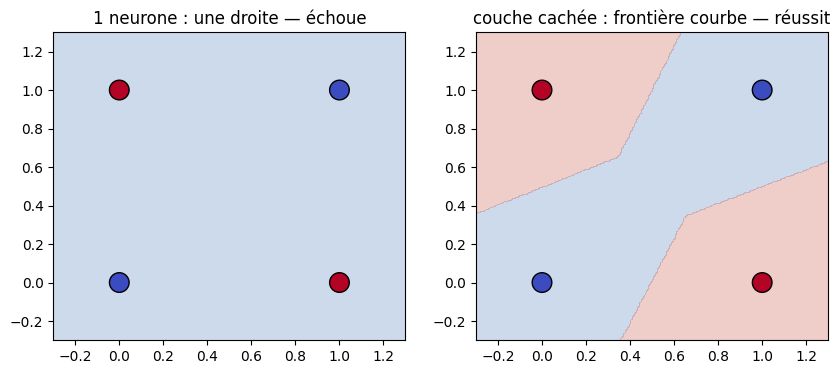

In [11]:
# Visualisons les deux frontières de décision
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))

# logistique (droite)
Zl = logit.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Zl, alpha=0.25, levels=[-0.5,0.5,1.5], colors=["#3b6fb0","#c0392b"])
axes[0].scatter(X_xor[:,0], X_xor[:,1], c=y_xor, cmap="coolwarm", s=200, edgecolors="k")
axes[0].set_title("1 neurone : une droite — échoue")

# réseau (frontière courbe)
Zm = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Zm, alpha=0.25, levels=[-0.5,0.5,1.5], colors=["#3b6fb0","#c0392b"])
axes[1].scatter(X_xor[:,0], X_xor[:,1], c=y_xor, cmap="coolwarm", s=200, edgecolors="k")
axes[1].set_title("couche cachée : frontière courbe — réussit")
plt.show()

**Lecture.** Le neurone seul ne dispose que d'une droite : impossible de séparer le
damier XOR. La couche cachée combine plusieurs droites en une frontière courbe qui isole
chaque classe. C'est tout l'apport de la profondeur.

## Partie 3 — Pourquoi l'activation non-linéaire est indispensable

Empiler deux couches **linéaires** (sans activation) ne donne rien de plus qu'une seule
couche. Vérifions-le en code.

In [12]:
# Deux couches LINÉAIRES (sans activation)
W1 = np.array([[2., 1.], [0., 3.]]); b1 = np.array([1., -1.])
W2 = np.array([[1., -2.]]);          b2 = np.array([0.5])
x_demo = np.array([1.0, 2.0])

# calcul couche par couche
h = W1 @ x_demo + b1            # couche 1 (pas d'activation)
sortie_2couches = W2 @ h + b2   # couche 2

# couche unique équivalente : W2·W1 et W2·b1 + b2
W_eq = W2 @ W1
b_eq = W2 @ b1 + b2
sortie_1couche = W_eq @ x_demo + b_eq

print(f"deux couches linéaires : {sortie_2couches}")
print(f"une couche équivalente : {sortie_1couche}")
print(f"W équivalent = {W_eq},  b équivalent = {b_eq}")
print("IDENTIQUES : sans activation, empiler ne sert à rien.")

deux couches linéaires : [-4.5]
une couche équivalente : [-4.5]
W équivalent = [[ 2. -5.]],  b équivalent = [3.5]
IDENTIQUES : sans activation, empiler ne sert à rien.


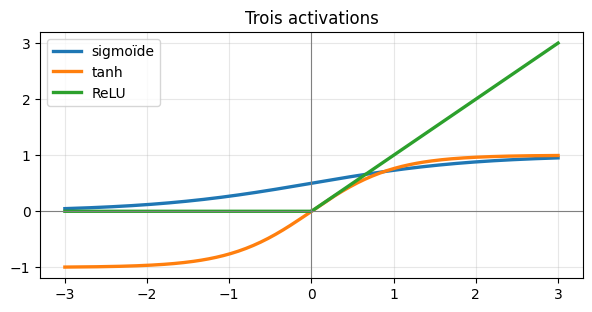

In [13]:
# Les trois activations usuelles, tracées
z = np.linspace(-3, 3, 200)
plt.figure(figsize=(7, 3.2))
plt.plot(z, sigmoide(z), label="sigmoïde", lw=2.4)
plt.plot(z, np.tanh(z), label="tanh", lw=2.4)
plt.plot(z, np.maximum(0, z), label="ReLU", lw=2.4)
plt.axhline(0, color="gray", lw=0.8); plt.axvline(0, color="gray", lw=0.8)
plt.legend(); plt.grid(alpha=0.3); plt.title("Trois activations")
plt.show()

**Lecture.** Les deux couches linéaires donnent exactement la même sortie que la couche
unique équivalente. C'est la non-linéarité (ReLU, sigmoïde, tanh) glissée entre les couches
qui donne au réseau sa puissance — sans elle, la profondeur est une illusion.

## Partie 3bis — La rétropropagation, codée à la main

On code la **propagation avant** et la **rétropropagation** sur le petit réseau 2-2-1 du
cours, puis on vérifie les gradients par **différences finies** — le réflexe pour valider
toute implémentation de backprop.

In [14]:
# Le réseau 2-2-1 du cours (mêmes poids)
x  = np.array([1.0, 0.0])                       # entrée
W1 = np.array([[0.5, 0.1], [-0.3, 0.8]])        # (2 cachés, 2 entrées)
b1 = np.array([0.1, -0.2])
W2 = np.array([0.4, -0.6])                       # (1 sortie, 2 cachés)
b2 = 0.2
y  = 1.0                                         # cible

def forward(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = sigmoide(z1)
    z2 = W2 @ a1 + b2
    a2 = sigmoide(z2)
    return z1, a1, z2, a2

z1, a1, z2, a2 = forward(x, W1, b1, W2, b2)
L = -(y*np.log(a2) + (1-y)*np.log(1-a2))
print(f"a1 = {a1.round(4)}")
print(f"y_hat = {a2:.4f}   perte L = {L:.4f}")

a1 = [0.6457 0.3775]
y_hat = 0.5577   perte L = 0.5840


In [15]:
# Rétropropagation : les 4 équations du cours
def dsigmoide(a):
    return a * (1 - a)             # dérivée en fonction de la sortie a

# (1) erreur de sortie
delta2 = a2 - y
# (3-4) gradients couche de sortie
dW2 = delta2 * a1
db2 = delta2
# (2) erreur rétropropagée vers la couche cachée
delta1 = (W2 * delta2) * dsigmoide(a1)
# (3-4) gradients couche cachée
dW1 = np.outer(delta1, x)
db1 = delta1

print(f"delta2 = y_hat - y = {delta2:.4f}")
print(f"dL/dW2 = {dW2.round(4)}")
print(f"delta1 = {delta1.round(4)}")
print(f"dL/dW1 =\n{dW1.round(4)}")

delta2 = y_hat - y = -0.4423
dL/dW2 = [-0.2856 -0.167 ]
delta1 = [-0.0405  0.0624]
dL/dW1 =
[[-0.0405 -0.    ]
 [ 0.0624  0.    ]]


**Vérifions par différences finies.** On perturbe chaque poids de $\varepsilon$ et on
mesure la variation de perte : si le backprop est correct, les deux coïncident.

In [16]:
# Test du gradient : backprop vs différence finie
def perte(W1, b1, W2, b2):
    _, _, _, a2 = forward(x, W1, b1, W2, b2)
    return -(y*np.log(a2) + (1-y)*np.log(1-a2))

eps = 1e-6
# vérif sur W2[0]
W2p = W2.copy(); W2p[0] += eps; Lp = perte(W1, b1, W2p, b2)
W2m = W2.copy(); W2m[0] -= eps; Lm = perte(W1, b1, W2m, b2)
num = (Lp - Lm) / (2*eps)
print(f"dL/dW2[0] : backprop = {dW2[0]:.6f}   diff. finie = {num:.6f}")
print(f"           écart = {abs(dW2[0]-num):.2e}  -> backprop CORRECT")

dL/dW2[0] : backprop = -0.285589   diff. finie = -0.285589
           écart = 5.77e-11  -> backprop CORRECT


In [17]:
# Un pas de descente de gradient : la perte baisse-t-elle ?
eta = 0.5
W2_new = W2 - eta*dW2
b2_new = b2 - eta*db2
W1_new = W1 - eta*dW1
b1_new = b1 - eta*db1

L_new = perte(W1_new, b1_new, W2_new, b2_new)
print(f"perte avant le pas : {L:.4f}")
print(f"perte après le pas : {L_new:.4f}")
print(f"baisse : {L - L_new:.4f}")

perte avant le pas : 0.5840
perte après le pas : 0.4414
baisse : 0.1426


**Lecture.** Le backprop calculé à la main coïncide avec les différences finies
(écart $\sim 10^{-10}$) : la dérivation est exacte. Et un seul pas de descente de gradient
fait chuter la perte de $0{,}584$ à $0{,}441$ — le réseau a appris. `MLPClassifier` fait
exactement cela, en boucle sur des milliers d'exemples.

**Exercice.** Modifier la cible en `y = 0` (au lieu de 1) et recalculer `delta2`,
`dW2` et la perte. Le signe de `delta2` change-t-il ? Que cela signifie-t-il pour la
correction des poids ?

In [ ]:
# Refaire le backprop avec y = 0

## Partie 4 — Un vrai réseau sur DataSANTÉ

Entraînons un `MLPClassifier` sur le paludisme. **Standardisation obligatoire** (rappel
Séance 9 : un réseau y est très sensible).

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

X = df[colonnes].values
y = df["paludisme"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# standardisation OBLIGATOIRE pour le réseau
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("données prêtes et standardisées.")

données prêtes et standardisées.


In [20]:
# Entraîner le réseau (deux couches cachées : 16 puis 8 neurones)
reseau = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu",
                       max_iter=1000, random_state=0)
reseau.fit(X_train_s, y_train)

acc = reseau.score(X_test_s, y_test)
auc = roc_auc_score(y_test, reseau.predict_proba(X_test_s)[:, 1])
print(f"accuracy test : {acc:.3f}")
print(f"AUC test      : {auc:.3f}")

accuracy test : 0.882
AUC test      : 0.693


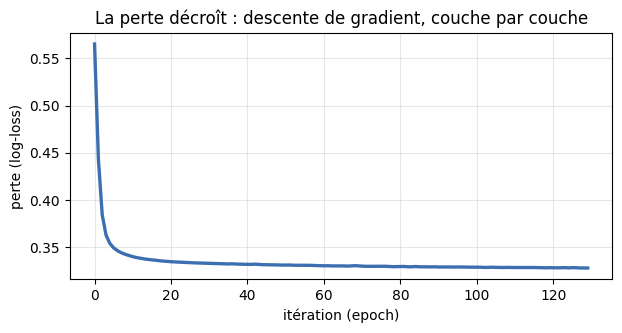

perte initiale : 0.565  ->  finale : 0.328


In [21]:
# La courbe de perte : la descente de gradient en action (Séance 5)
plt.figure(figsize=(7, 3.2))
plt.plot(reseau.loss_curve_, color="#3b6fb0", lw=2.4)
plt.xlabel("itération (epoch)"); plt.ylabel("perte (log-loss)")
plt.title("La perte décroît : descente de gradient, couche par couche")
plt.grid(alpha=0.3)
plt.show()
print(f"perte initiale : {reseau.loss_curve_[0]:.3f}  ->  finale : {reseau.loss_curve_[-1]:.3f}")

**Lecture.** La perte chute puis se stabilise : le réseau a convergé. C'est la même
courbe descendante que la descente de gradient de la Séance 5, sur un modèle plus gros.

**Exercice.** Entraîner un `MLPClassifier` avec **une seule** couche cachée de $4$
neurones (`hidden_layer_sizes=(4,)`) sur `X_train_s`, et afficher son accuracy sur le test.

In [ ]:
# Réseau à une couche cachée de 4 neurones

### Pourquoi la standardisation est obligatoire

Comparons un réseau entraîné SUR données standardisées vs SANS standardisation, pour voir
l'effet concret.

In [23]:
# Le même réseau, avec et sans standardisation
reseau_avec = MLPClassifier(hidden_layer_sizes=(16,8), activation="relu",
                            max_iter=1000, random_state=0).fit(X_train_s, y_train)
reseau_sans = MLPClassifier(hidden_layer_sizes=(16,8), activation="relu",
                            max_iter=1000, random_state=0).fit(X_train, y_train)

auc_avec = roc_auc_score(y_test, reseau_avec.predict_proba(X_test_s)[:,1])
auc_sans = roc_auc_score(y_test, reseau_sans.predict_proba(X_test)[:,1])
print(f"AUC AVEC standardisation : {auc_avec:.3f}")
print(f"AUC SANS standardisation : {auc_sans:.3f}")
print(f"perte finale avec : {reseau_avec.loss_curve_[-1]:.3f}  |  sans : {reseau_sans.loss_curve_[-1]:.3f}")

AUC AVEC standardisation : 0.693
AUC SANS standardisation : 0.673
perte finale avec : 0.328  |  sans : 0.336


**Lecture.** Sans standardisation, le réseau apprend moins bien (perte plus haute,
AUC dégradée) : les variables à grande échelle (l'âge, jusqu'à 85) écrasent les autres dans
la descente de gradient. C'est exactement le piège de l'échelle vu en Séance 9 — mais un
réseau y est encore plus sensible qu'un autre modèle. **Toujours standardiser avant un
réseau.**

## Partie 5 — La taille de la couche : un plafond vite atteint

Un réseau plus gros est-il un réseau meilleur ? Testons plusieurs architectures.

In [24]:
# Effet de la taille de la couche cachée sur l'accuracy
for taille in [(2,), (8,), (16,), (32,), (16, 8)]:
    m = MLPClassifier(hidden_layer_sizes=taille, activation="relu",
                      max_iter=800, random_state=0).fit(X_train_s, y_train)
    print(f"  couche(s) {str(taille):<10} : accuracy = {m.score(X_test_s, y_test):.3f}")

  couche(s) (2,)       : accuracy = 0.882


  couche(s) (8,)       : accuracy = 0.882


  couche(s) (16,)      : accuracy = 0.882


  couche(s) (32,)      : accuracy = 0.882


  couche(s) (16, 8)    : accuracy = 0.882


**Lecture.** L'accuracy plafonne à $0{,}882$ quelle que soit la taille : sur ces
données, agrandir le réseau n'apporte rien. La capacité utile dépend de la complexité des
**données**, pas de l'ambition du modèle.

### Ce que le réseau apprend : la frontière sur deux variables

Pour *voir* ce qu'un réseau capture, entraînons-le sur deux variables seulement
(fièvre et saison) et traçons sa frontière de décision.

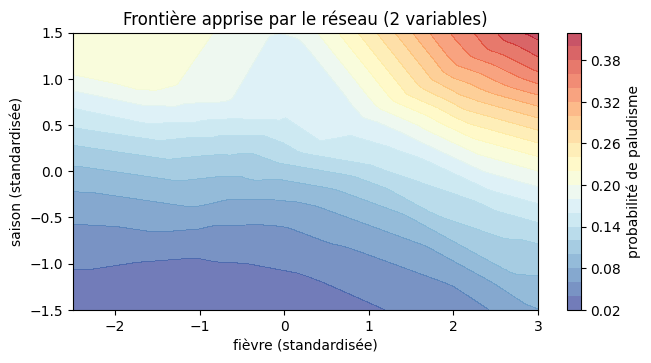

In [25]:
# Réseau sur 2 variables (fièvre, saison) pour visualiser la frontière
deux = ["fievre", "saison"]
X2 = df[deux].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.25, random_state=42, stratify=y)
sc2 = StandardScaler().fit(X2_train)
X2_train_s, X2_test_s = sc2.transform(X2_train), sc2.transform(X2_test)

mlp2 = MLPClassifier(hidden_layer_sizes=(16,8), activation="relu",
                     max_iter=1000, random_state=0).fit(X2_train_s, y2_train)

# grille de décision (en unités standardisées)
xx, yy = np.meshgrid(np.linspace(-2.5, 3, 200), np.linspace(-1.5, 1.5, 60))
Z = mlp2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

plt.figure(figsize=(7.5, 3.6))
plt.contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.7)
plt.colorbar(label="probabilité de paludisme")
plt.xlabel("fièvre (standardisée)"); plt.ylabel("saison (standardisée)")
plt.title("Frontière apprise par le réseau (2 variables)")
plt.show()

**Lecture.** Le réseau a appris une zone de probabilité élevée pour les fièvres hautes
ET la saison des pluies — cohérent avec la médecine et avec ce que les modèles précédents
trouvaient. Sur deux variables, sa frontière reste simple : la richesse d'un réseau ne se
révèle que sur des données autrement plus complexes que les nôtres.

## Mini-défi — Le réseau bat-il les ensembles ?

La question décisive : sur nos données tabulaires, le réseau fait-il mieux que les
méthodes d'ensemble de la Séance 8 ? Comparons honnêtement, mêmes données, même juge (AUC).

In [26]:
# Quatre modèles, comparés sur le même test
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1 neurone (Séance 6)
logit = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
# réseau (Séance 10)
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu",
                    max_iter=1000, random_state=0).fit(X_train_s, y_train)
# forêt (Séance 8) — pas besoin de standardiser
rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(X_train, y_train)
# boosting (Séance 8)
gb = GradientBoostingClassifier(random_state=0).fit(X_train, y_train)

resultats = {
    "Régression logistique (1 neurone)": roc_auc_score(y_test, logit.predict_proba(X_test_s)[:,1]),
    "Réseau (MLP 16-8)":                 roc_auc_score(y_test, mlp.predict_proba(X_test_s)[:,1]),
    "Random Forest":                     roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
    "Gradient Boosting":                 roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]),
}
for nom, score in resultats.items():
    print(f"  {nom:<35} AUC = {score:.3f}")

  Régression logistique (1 neurone)   AUC = 0.698
  Réseau (MLP 16-8)                   AUC = 0.693
  Random Forest                       AUC = 0.662
  Gradient Boosting                   AUC = 0.700


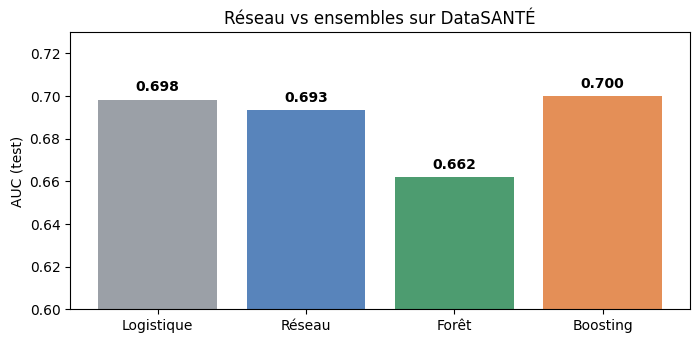

In [27]:
# Visualisons le comparatif
fig, ax = plt.subplots(figsize=(8, 3.6))
noms = list(resultats.keys())
scores = list(resultats.values())
couleurs = ["#8a8f98", "#3b6fb0", "#2e8b57", "#e07b39"]
bars = ax.bar(range(len(noms)), scores, color=couleurs, alpha=0.85)
for bar, s in zip(bars, scores):
    ax.text(bar.get_x()+bar.get_width()/2, s+0.004, f"{s:.3f}",
            ha="center", fontweight="bold")
ax.set_xticks(range(len(noms)))
ax.set_xticklabels(["Logistique", "Réseau", "Forêt", "Boosting"])
ax.set_ylabel("AUC (test)"); ax.set_ylim(0.6, 0.73)
ax.set_title("Réseau vs ensembles sur DataSANTÉ")
plt.show()

**Lecture — la leçon de la séance.** Les quatre modèles se tiennent dans un mouchoir :
le gradient boosting ($0{,}700$) et même la simple régression logistique ($0{,}698$) font
aussi bien ou mieux que le réseau ($0{,}693$). Sur données **tabulaires**, le réseau n'est
**pas** magique : il égale au mieux des modèles plus simples, pour bien plus de complexité
et de temps de réglage.

Ce n'est pas un accident : sur les données tabulaires, les méthodes d'ensemble (forêts,
boosting, XGBoost) sont régulièrement aussi bonnes ou meilleures que les réseaux. Le réseau
gagne ailleurs — **images, texte, son, très grands volumes** — là où la structure est
riche et non tabulaire. C'est la même leçon de maturité qu'en Séance 8, poussée plus loin :
**la popularité d'un modèle ne dit rien de sa pertinence pour votre problème.**

La Séance 11 rassemblera tout le cours en un **projet complet** : formuler, préparer (S4),
modéliser et comparer (S3, S5–S10), évaluer honnêtement (S6–S7), interpréter et présenter.

## Synthèse — à compléter

1. Un **neurone** $=$ une **..........** pondérée suivie d'une **..........** ; quand cette
   dernière est la sigmoïde, c'est la **..........** de la Séance 6.
2. Un neurone seul ne trace qu'une **..........** ; il échoue sur **..........** (motif
   non séparable linéairement).
3. Une **..........** combine plusieurs droites en une frontière **..........**.
4. L'**..........** non-linéaire est indispensable : sans elle, empiler des couches se
   réduit à une seule transformation **..........**. La plus utilisée est **..........**.
5. Un réseau apprend par **..........** de gradient (S5) ; il faut toujours **..........**
   les entrées.
6. Sur données **..........**, les méthodes d'**..........** (S8) égalent ou battent les
   réseaux ; le réseau gagne sur **..........**, **..........**, **..........**.